# 1. Import Libraries

In [1]:
import os
import rasterio
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2- Load Dataset

In [2]:
Data_path = r"D:\master\02- Second Semester\04- AI\Project\EuroSAT_MS\EuroSAT_MS"

In [3]:
BAND_LABELS = [
    "B01 - Aerosols",
    "B02 - Blue",
    "B03 - Green",
    "B04 - Red",
    "B05 - Red Edge 1",
    "B06 - Red Edge 2",
    "B07 - Red Edge 3",
    "B08 - NIR",
    "B08A - Red Edge 4",
    "B09 - Water Vapor",
    "B10 - Cirrus",
    "B11 - SWIR 1",
    "B12 - SWIR 2"
]

# 3. Dataset Validation

## Count Images

In [4]:
class_counts = {}

for class_name in os.listdir(Data_path):

    class_path = os.path.join(Data_path, class_name)

    if os.path.isdir(class_path):

        tif_files = [
            f for f in os.listdir(class_path)
            if f.endswith(".tif")
        ]

        class_counts[class_name] = len(tif_files)

print("Total Classes:", len(class_counts))
print("Total Images:", sum(class_counts.values()))

pd.DataFrame(
    list(class_counts.items()),
    columns=["Class","Count"]
)

Total Classes: 10
Total Images: 27000


,Class,Count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


## Number of Bands

In [5]:
sample_image = None

for root, dirs, files in os.walk(Data_path):

    for file in files:

        if file.endswith(".tif"):

            sample_image = os.path.join(root,file)
            break

    if sample_image:
        break

with rasterio.open(sample_image) as src:

    print("Sample Image:")
    print(sample_image)

    print("Number of Bands:")
    print(src.count)

Sample Image:
D:\master\02- Second Semester\04- AI\Project\EuroSAT_MS\EuroSAT_MS\AnnualCrop\AnnualCrop_1.tif
Number of Bands:
13


# 4. Dataset Visualization

## Sample Images

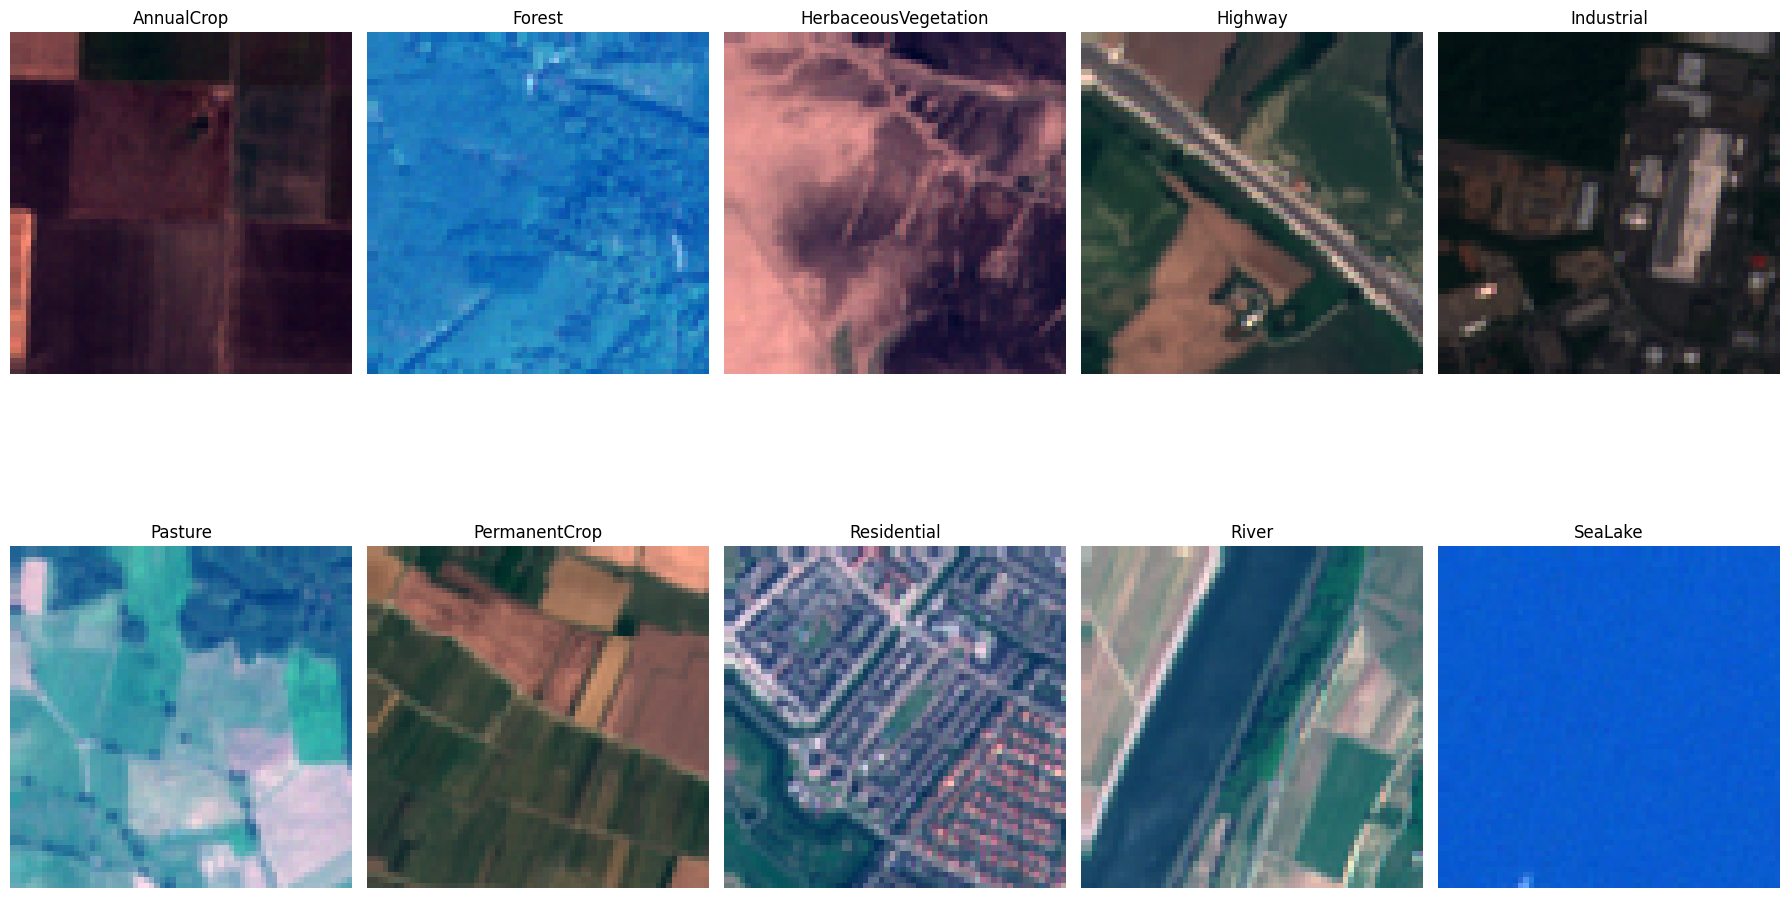

In [6]:
def process_rgb_image(image_path):

    with rasterio.open(image_path) as src:

        img = src.read([4,3,2]).astype(np.float32)

        img = np.transpose(img,(1,2,0))

        img = (
            img - img.min()
        ) / (
            img.max() - img.min()
        )

    return img


plt.figure(figsize=(18,12))

for i,class_name in enumerate(sorted(os.listdir(Data_path))):

    class_path = os.path.join(
        Data_path,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    sample_file = next(
        f for f in os.listdir(class_path)
        if f.endswith(".tif")
    )

    image_path = os.path.join(
        class_path,
        sample_file
    )

    image = process_rgb_image(image_path)

    plt.subplot(2,5,i+1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(class_name)

plt.tight_layout()
plt.show()

## Band Visualization

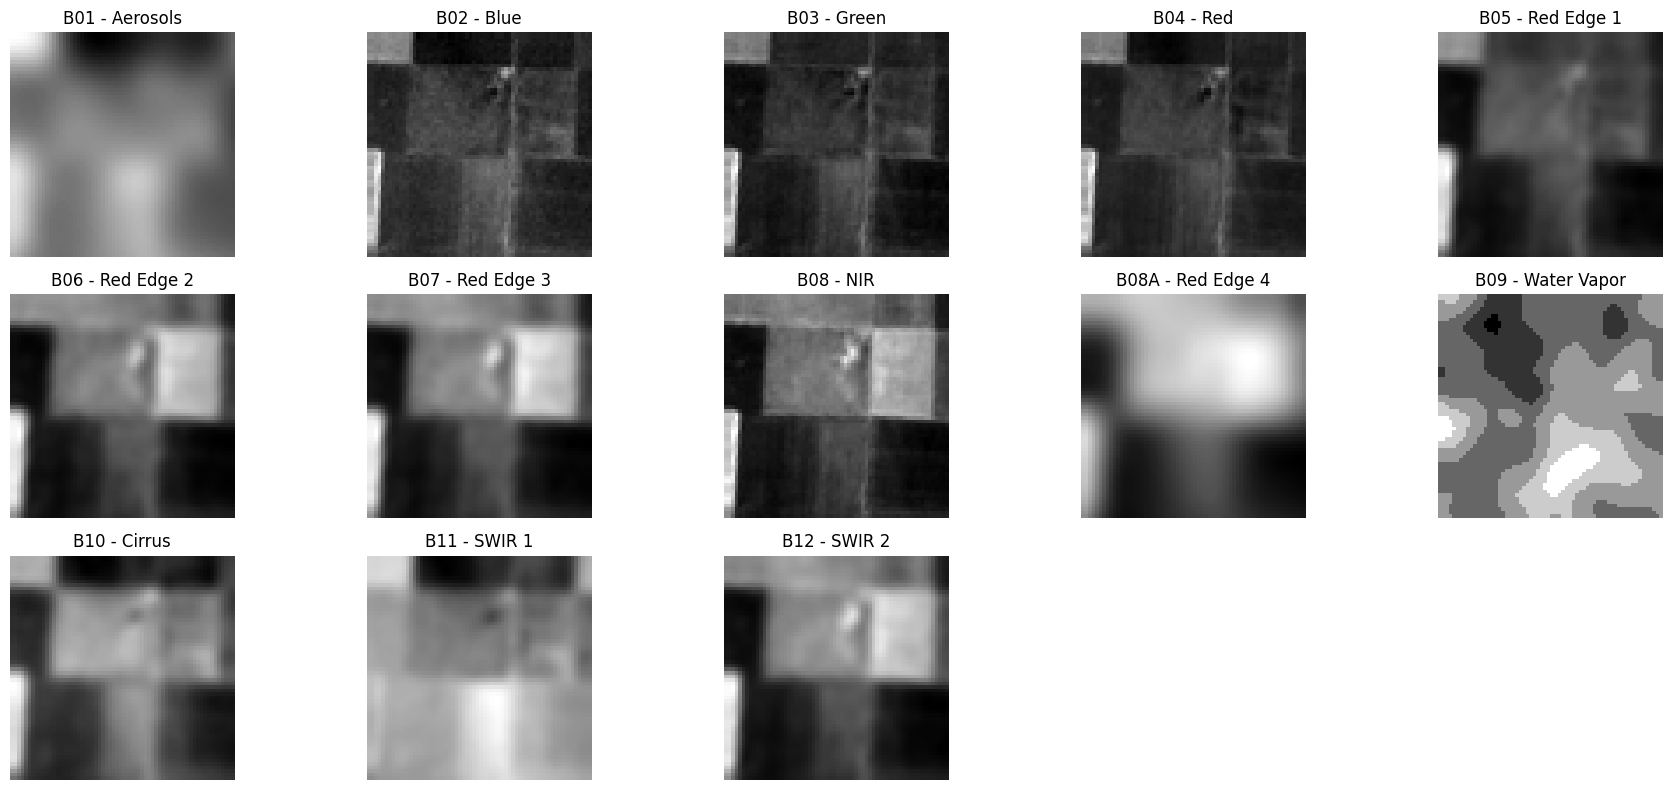

In [7]:
with rasterio.open(sample_image) as src:

    image = src.read()

plt.figure(figsize=(18,8))

for i in range(13):

    plt.subplot(3,5,i+1)

    band = image[i]

    plt.imshow(
        band,
        cmap="gray"
    )

    plt.title(BAND_LABELS[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

## Class Distribution

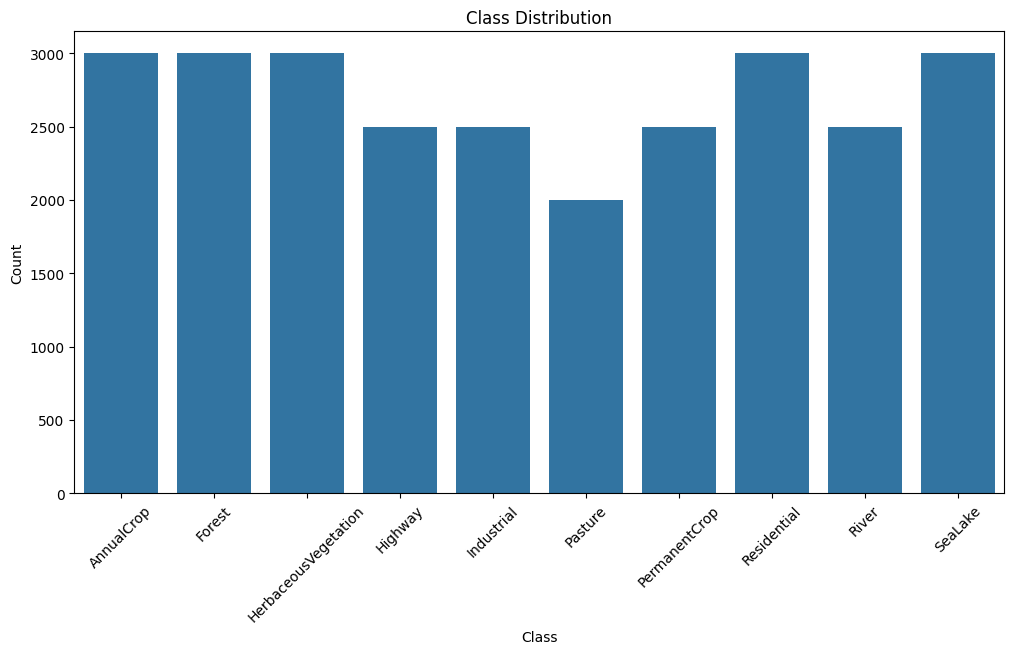

In [8]:
df_classes = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class","Count"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_classes,
    x="Class",
    y="Count"
)

plt.xticks(rotation=45)

plt.title(
    "Class Distribution"
)

plt.show()

# 5. Spectral Analysis

## Band Statistics

In [9]:
band_means = []
band_stds = []

for class_name in os.listdir(Data_path):

    class_path = os.path.join(
        Data_path,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    sample_file = next(
        f for f in os.listdir(class_path)
        if f.endswith(".tif")
    )

    image_path = os.path.join(
        class_path,
        sample_file
    )

    with rasterio.open(image_path) as src:

        image = src.read()

    band_means.append(
        image.reshape(
            image.shape[0],
            -1
        ).mean(axis=1)
    )

    band_stds.append(
        image.reshape(
            image.shape[0],
            -1
        ).std(axis=1)
    )

stats_df = pd.DataFrame({
    "Band": BAND_LABELS,
    "Mean": np.mean(
        band_means,
        axis=0
    ),
    "Std": np.mean(
        band_stds,
        axis=0
    )
})

display(stats_df)

,Band,Mean,Std
0,B01 - Aerosols,1281.229810,81.835305
1,B02 - Blue,1053.028564,167.378257
2,B03 - Green,977.492480,201.979119
3,B04 - Red,925.538062,320.675759
4,B05 - Red Edge 1,1172.634326,266.776354
5,B06 - Red Edge 2,1920.293726,395.356472
6,B07 - Red Edge 3,2267.801929,501.279230
7,B08 - NIR,2211.397388,566.311433
8,B08A - Red Edge 4,728.248096,123.463709
9,B09 - Water Vapor,11.451807,1.115545


## Correlation Matrix

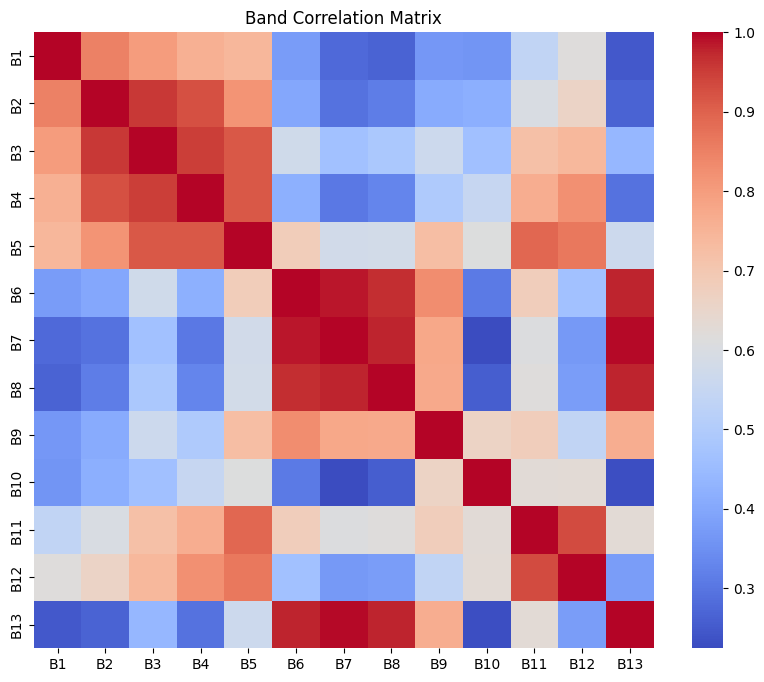

In [10]:
pixels = []

for class_name in os.listdir(Data_path):

    class_path = os.path.join(
        Data_path,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    sample_file = next(
        f for f in os.listdir(class_path)
        if f.endswith(".tif")
    )

    image_path = os.path.join(
        class_path,
        sample_file
    )

    with rasterio.open(image_path) as src:

        image = src.read()

    pixels.append(
        image.reshape(
            13,
            -1
        ).T
    )

pixels = np.vstack(pixels)

corr_matrix = pd.DataFrame(
    pixels,
    columns=[f"B{i}" for i in range(1,14)]
).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title(
    "Band Correlation Matrix"
)

plt.show()

## PCA

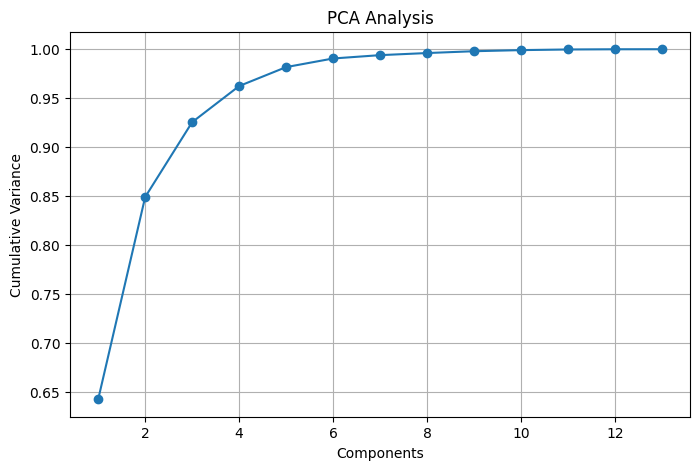

In [11]:
scaler = StandardScaler()

scaled_pixels = scaler.fit_transform(
    pixels
)

pca = PCA()

pca.fit(
    scaled_pixels
)

explained = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,14),
    explained,
    marker="o"
)

plt.xlabel(
    "Components"
)

plt.ylabel(
    "Cumulative Variance"
)

plt.title(
    "PCA Analysis"
)

plt.grid()

plt.show()

## Spectral Signature

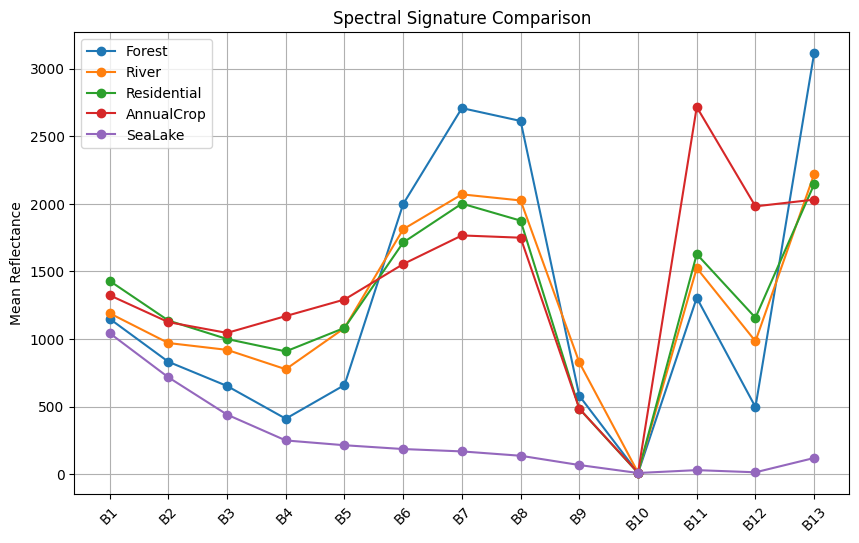

In [12]:
selected_classes = [
    "Forest",
    "River",
    "Residential",
    "AnnualCrop",
    "SeaLake"
]

plt.figure(figsize=(10,6))

for cls in selected_classes:

    cls_path = os.path.join(
        Data_path,
        cls
    )

    sample_file = next(
        f for f in os.listdir(cls_path)
        if f.endswith(".tif")
    )

    image_path = os.path.join(
        cls_path,
        sample_file
    )

    with rasterio.open(image_path) as src:

        image = src.read()

    signature = image.reshape(
        image.shape[0],
        -1
    ).mean(axis=1)

    plt.plot(
        signature,
        marker="o",
        label=cls
    )

plt.xticks(
    range(13),
    [f"B{i}" for i in range(1,14)],
    rotation=45
)

plt.title(
    "Spectral Signature Comparison"
)

plt.ylabel(
    "Mean Reflectance"
)

plt.legend()

plt.grid()

plt.show()

# 6. Spectral Indices

## NDVI + NDWI + NDBI

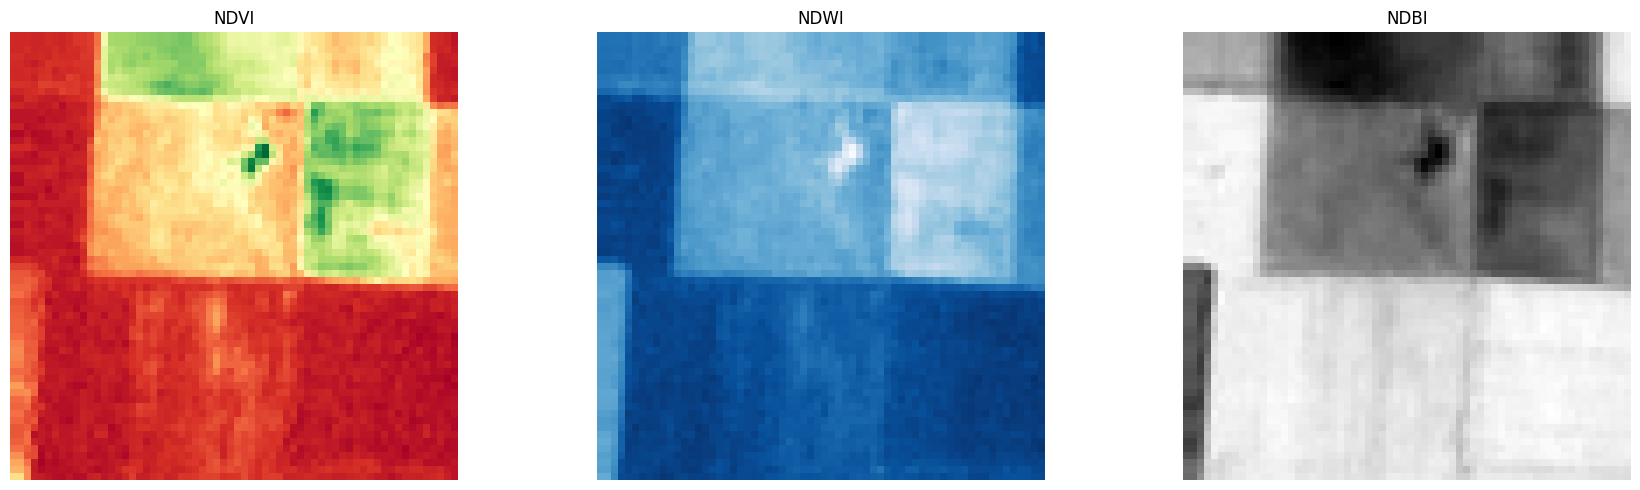

In [13]:
with rasterio.open(sample_image) as src:

    img = src.read()

green = img[2].astype(float)
red   = img[3].astype(float)
nir   = img[7].astype(float)
swir  = img[11].astype(float)

ndvi = (
    nir - red
) / (
    nir + red + 1e-8
)

ndwi = (
    green - nir
) / (
    green + nir + 1e-8
)

ndbi = (
    swir - nir
) / (
    swir + nir + 1e-8
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

axes[0].imshow(
    ndvi,
    cmap="RdYlGn"
)
axes[0].set_title("NDVI")

axes[1].imshow(
    ndwi,
    cmap="Blues"
)
axes[1].set_title("NDWI")

axes[2].imshow(
    ndbi,
    cmap="gray"
)
axes[2].set_title("NDBI")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 7. Conclusion (Markdown Cell)

# Conclusion

The EuroSAT Multispectral dataset was successfully loaded,
validated, and analyzed.

Key findings:

• The dataset is balanced across all land-cover classes.

• Sentinel-2 multispectral imagery provides rich spectral information.

• Correlation analysis revealed relationships between spectral bands.

• PCA showed that most information can be preserved using fewer components.

• NDVI, NDWI, and NDBI successfully highlight vegetation, water bodies, and built-up areas.

• Spectral signatures clearly distinguish different land-cover categories.

The dataset is now fully understood and ready for preprocessing and CNN-based classification.